# Creating Null Models for Novel Domain Architectures

Given the results from the cancer fusion gene analysis, we will establish some null models to determine some of the effect sizes and false discoveries we may be observing in that data.

In [1]:
import pandas as pd
import numpy as np
import dansy
import random
import itertools
from collections import Counter
import fusionClasses as fc
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import scipy.stats as stats
import networkx as nx

In [2]:
ref_df = dansy.import_proteome_files(ref_file_dir='./data/Current_Human_Proteome',
                                     ref_file_suffix='2026_0108.csv')
exon_information = pd.read_csv('Gene_exon_information.csv', index_col=0)
gene_conv = pd.read_csv('ENSEMBL_Gene_Conversion.csv')
valid_uniprots = list(set(ref_df['UniProt ID']).intersection(gene_conv['UniProtKB/Swiss-Prot ID'].unique()))

In [3]:
proteome_net = dansy.dansy(ref=ref_df, n=15)

Starting to fetch n-grams.
Finished getting all n-grams
Starting to generate adjacency
Finished building adjacency.


In [4]:
random.seed(123)
n = 10000 # How many pairs to create
pairs = np.reshape(random.choices(valid_uniprots, k=n*2), (n,2)).tolist()


In [5]:
x = gene_conv.filter(['Gene stable ID', 'Gene name','UniProtKB/Swiss-Prot ID','Chromosome/scaffold name']).drop_duplicates()
conv_dict = x.set_index('UniProtKB/Swiss-Prot ID')['Gene stable ID'].to_dict()
name_conv = x.set_index('UniProtKB/Swiss-Prot ID')['Gene name'].to_dict()
chr_info = x.set_index('UniProtKB/Swiss-Prot ID')['Chromosome/scaffold name'].to_dict()

In [6]:
# Now let's take all the pairs and within each randomly choose exons to include
exons_grouped = exon_information.groupby('Gene stable ID')

In [7]:
# run through each pair and grab a random exon start point to call the breakpoint
null_fusions = []
for pair in pairs:
    bp_info = pd.Series(index=['h_uniprot', 't_uniprot','h_pos','t_pos', 'h_chr', 't_chr', 'h_gene', 't_gene', 'h_symbol','t_symbol'],
                        dtype=object)
    bp_info['h_uniprot'] = pair[0]
    bp_info['t_uniprot'] = pair[1]
    bp_info['h_pos'] = random.choice(exons_grouped.get_group(conv_dict[pair[0]])['Exon region start (bp)'].values)
    bp_info['t_pos'] = random.choice(exons_grouped.get_group(conv_dict[pair[1]])['Exon region start (bp)'].values)
    bp_info['h_gene'] = conv_dict[pair[0]]
    bp_info['t_gene'] = conv_dict[pair[1]]
    bp_info['h_symbol'] = name_conv[pair[0]]
    bp_info['t_symbol'] = name_conv[pair[1]]
    bp_info['h_chr'] = chr_info[pair[0]]
    bp_info['t_chr'] = chr_info[pair[1]]
    null_fusions.append(bp_info)
    
null_fusions = pd.DataFrame.from_records(null_fusions)

In [8]:
null_fusions['name'] = null_fusions.h_symbol.str.cat(null_fusions.t_symbol, sep = '--')
fusion_dansy = fc.fusionCollection(null_fusions, mapper={k:k for k in null_fusions.columns}, add_cols=[])

100%|██████████| 10000/10000 [01:03<00:00, 157.94it/s]


In [9]:
fusion_dansy.perform_dansy_analysis(dansy_obj=proteome_net)
y = fusion_dansy.summarize_dansy_results()

100%|██████████| 4584/4584 [00:14<00:00, 308.76it/s]


There were 1693 fusion domain architectures previously found in the proteome.


<Axes: xlabel='dansy_impact', ylabel='percent'>

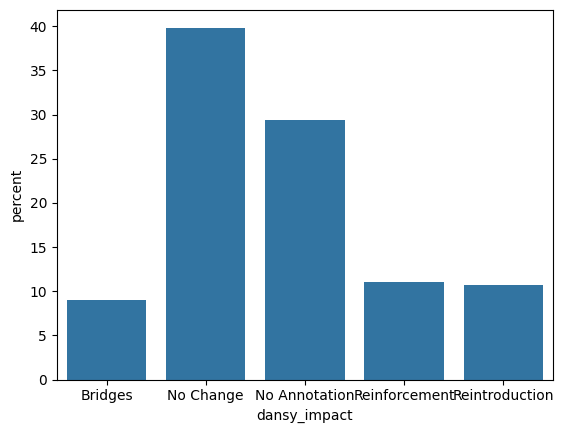

In [10]:
sns.countplot(y, x = 'dansy_impact', stat='percent')



Now let's do a quick enrichment analysis to see if we get any significant results that suggest false positives in real datasets.

In [ ]:
# Let's grab all the n-grams and all the domains from the natural proteome
null_ngrams = [k for k in dansy.ngramUtilities.return_ngrams_from_list(y.domain_architecture.values)]
natural_ngrams  = set(proteome_net.ngrams).union(proteome_net.collapsed_ngrams)

# Now limiting them to only those found in the proteome
null_ngrams = list(set(null_ngrams).intersection(natural_ngrams))

In [34]:
# Now let's start the enrichment process
M = len(y)
null_groups = y.groupby('dansy_impact')
y_N = Counter(y.dansy_impact)
raw = []
for ngram in tqdm(null_ngrams):
    n = sum([ngram in i for i in y.domain_architecture])
    res = pd.Series(index = y_N.keys(),name = ngram)
    res['n'] = n
    for comp in y_N.keys():
        temp = null_groups.get_group(comp)
        N = y_N[comp]
        x = sum([ngram in i for i in temp.domain_architecture])
        res[comp] = stats.hypergeom.sf(x-1,M,n,N)
    raw.append(res)
    

100%|██████████| 13541/13541 [01:02<00:00, 217.32it/s]


In [60]:
full_res = pd.concat(raw, axis =1).T
full_res.reset_index(inplace= True)
full_res['n-gram'] = full_res['index'].apply(proteome_net.return_legible_ngram)
full_res.sort_values('Bridges', inplace=True)

for comp in y_N.keys():
    full_res[comp+'_q'] = stats.false_discovery_control(full_res[comp], method = 'bh')
    full_res[comp+'_log_q'] = -1*np.log10(full_res[comp+'_q'])


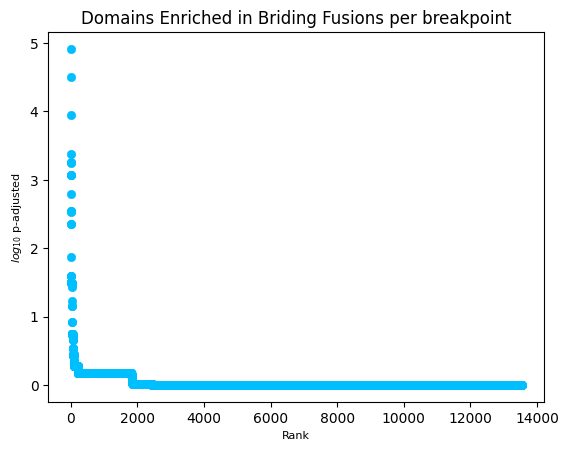

In [51]:
sns.scatterplot(full_res, y = 'Bridges_log_q', x = range(len(full_res)),edgecolor = None, color = 'deepskyblue')
plt.title('Domains Enriched in Briding Fusions per breakpoint')
plt.ylabel(r'$log_{10}$ p-adjusted', size = 8)
plt.xlabel('Rank', size=8)
plt.show()

In [39]:
full_res

,index,Bridges,No Change,No Annotation,Reinforcement,Reintroduction,n,n-gram,Bridges_q,Bridges_log_q,No Change_q,No Change_log_q,No Annotation_q,No Annotation_log_q,Reinforcement_q,Reinforcement_log_q,Reintroduction_q,Reintroduction_log_q
6883,IPR043976,8.991608e-10,0.959286,1.0,1.000000,1.000000,14.0,GOLGA_cons_dom,0.000012,4.914512,1.0,-0.0,1.0,-0.0,1.00000,-0.0000,1.000000,-0.000000
9786,IPR002190,4.680957e-09,0.228342,1.0,1.000000,1.000000,29.0,MHD_dom,0.000032,4.499045,1.0,-0.0,1.0,-0.0,1.00000,-0.0000,1.000000,-0.000000
11133,IPR006809,2.468933e-08,0.343605,1.0,1.000000,1.000000,24.0,TAFII28_dom,0.000111,3.952961,1.0,-0.0,1.0,-0.0,1.00000,-0.0000,1.000000,-0.000000
4185,IPR032444,1.217841e-07,0.994358,1.0,1.000000,0.045308,19.0,Keratin_2_head,0.000412,3.384819,1.0,-0.0,1.0,-0.0,1.00000,-0.0000,0.443634,0.352975
340,IPR000795,2.025500e-07,0.940875,1.0,1.000000,0.770897,13.0,T_Tr_GTP-bd_dom,0.000549,3.260787,1.0,-0.0,1.0,-0.0,1.00000,-0.0000,1.000000,-0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5134,IPR000436|IPR003410|IPR003410|IPR000436|IPR011641,1.000000e+00,1.000000,1.0,1.000000,0.107100,1.0,Sushi_SCR_CCP_dom|HYR_dom|HYR_dom|Sushi_SCR_CC...,1.000000,-0.000000,1.0,-0.0,1.0,-0.0,1.00000,-0.0000,0.443634,0.352975
5135,IPR000483|IPR041015,1.000000e+00,0.398400,1.0,1.000000,1.000000,1.0,Cys-rich_flank_reg_C|TLR3_TMD,1.000000,-0.000000,1.0,-0.0,1.0,-0.0,1.00000,-0.0000,1.000000,-0.000000
5137,IPR001849|IPR056586,1.000000e+00,1.000000,1.0,1.000000,0.107100,1.0,PH_domain|EF-hand_PLCG1,1.000000,-0.000000,1.0,-0.0,1.0,-0.0,1.00000,-0.0000,0.443634,0.352975
5139,IPR000372|IPR000483|IPR002889|IPR000601|IPR001...,1.000000e+00,1.000000,1.0,0.110500,1.000000,1.0,LRRNT|Cys-rich_flank_reg_C|WSC_carb-bd|PKD_dom...,1.000000,-0.000000,1.0,-0.0,1.0,-0.0,0.46153,0.3358,1.000000,-0.000000


In [41]:
bc = nx.betweenness_centrality(proteome_net.G)
d = nx.degree_centrality(proteome_net.G)

In [42]:
full_res['betweenness'] = full_res['index'].map(bc)
full_res['degree'] = full_res['index'].map(d)

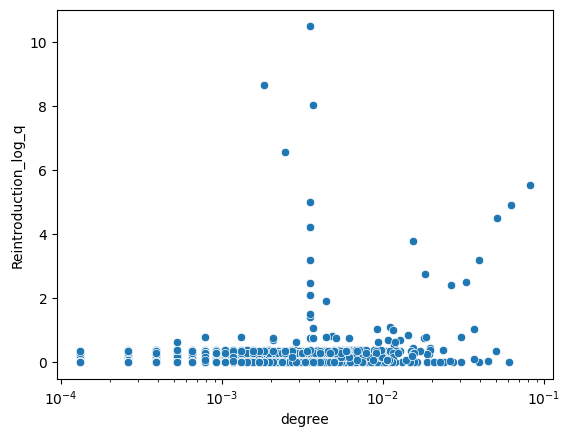

In [43]:
sns.scatterplot(full_res, x = 'degree', y = 'Reintroduction_log_q')
plt.xscale('log')

In [ ]:
# Defining a function for performing n-gram enrichment in general
def ngram_enrichment(df:pd.DataFrame, ngrams:list, columns:dict, fdr_method:str = 'bh'):
    '''
    Performs enrichment analysis using the Fisher's exact test on a collection of domain architectures for n-grams of interest with both the nominal p-value and a p-adjusted values returned.

    Parameters:
    -----------
    - df: pandas DataFrame
        DataFrame that contains the dataset of interest
    - ngrams: list
        List of n-grams to look for enrichment of
    - columns: dict
        Mapping dictionary with keys 'domain_architecture' and 'category' that tells which columns have the domain architectures and which are the categories to define groups
    - fdr_method: dict (Optional)
        The false_discovery_control method from the scipy stats module. If not provided, defaults to Benjamini-Hochberg 
    
    Returns:
    --------
    - res: pandas DataFrame
        DataFrame with columns for each category that represents the nominal p-value and an ammended category with _q that represents the adjusted p-value.
    '''

    if 'category' not in columns.keys() or 'domain_architecture' not in columns.keys():
        raise ValueError('The column mapping dict is missing at least one of the required keys.')
    
    # Make sure there are no duplicates in the ngrams provided
    ngrams = sorted(set(ngrams))

    comps = columns['category']
    archs = columns['domain_architecture']
    df = df.dropna(subset=archs)
    df_g = df.group_by(comps)
    M = len(df)

    # Get the counts for each of the categories
    cats_N = Counter(df[comps])

    # Run through each of the ngrams of interest and calculate the enrichment using a one-tailed hypergeometric test (aka Fisher's exact)
    raw = []
    for n in tqdm(ngrams):
        t = pd.Series(index = [k for k in cats_N.keys()], dtype = object) # Using the object dtype to prevent a FutureWarning from pandas
        n = sum([n in arch for arch in df[archs].values])
        t['n'] = n
        for cat, N in cats_N.items():
            temp = df_g.get_group(cat)
            x = sum([n in arch for arch in temp[archs].values])
            t[cat] = stats.hypergeom.sf(x-1,M,n,N)
        raw.append(t)

    res = pd.concat(raw, axis = 1).T
    
    for cat in cats_N.keys():
        res[cat+'_q'] = stats.false_discovery_control(res[cat], method = fdr_method)

    res.reset_index(inplace=True)

    return res

def waterfallplot_enrichment(dataOI:pd.DataFrame,cat, plot_adjusted = True, **kwargs):

    if plot_adjusted:
        col = cat+'_q'
    else:
        col = cat
    
    data = dataOI.copy()
    data[col] = data[col].apply(lambda x: -1*np.log10(x))
    data = data.sort_values(col, ascending=False)

    sns.scatterplot(data, x = range(len(data)), y = col,edgecolor = None, color = 'deepskyblue')
    plt.xlabel('Rank')
    plt.ylabel(r'$log_{10}$ p-adjusted')


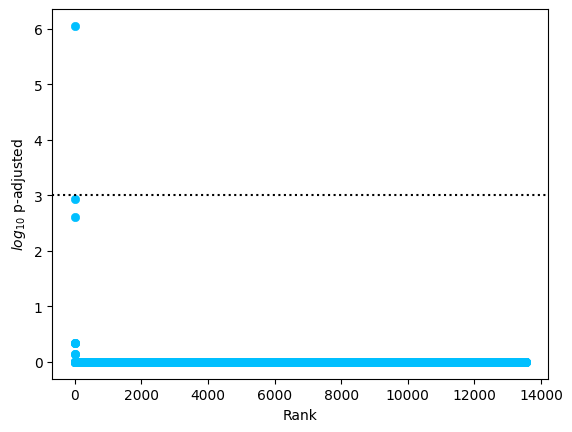

In [70]:
waterfallplot_enrichment(full_res, 'No Change')
plt.axhline(3, ls = ':', color = 'k')
plt.show()